# s06 — Moran I: del patrón global al patrón local
## CM0866 · Clase 6 · EAFIT 2026

---

| Parte | Contenido | Dataset | Tiempo |
|---|---|---|---|
| **A** | Moran I univariado · scatter · permutaciones · sensibilidad a W | Ciclistas + Brexit | 30 min |
| **B** | Del global al local · cuadrantes · mapa de cuadrantes | Ciclistas | 30 min |
| **C** | Datos propios del equipo | Proyecto de cada equipo | 30 min |
| **D** | Apertura Hito 2 | — | 15 min |

> *Cerramos con una pregunta abierta: ¿cuáles cuadrantes son estadísticamente significativos? → Clase 7.*

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 0 — Librerías y datos
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from libpysal.weights import KNN, Queen
from libpysal import weights
import esda
import splot.esda as esda_plot
import seaborn
import os, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
})
os.makedirs('outputs', exist_ok=True)
np.random.seed(42)

# ── Ciclistas ────────────────────────────────────────────────────────────────
ciclistas = gpd.read_file('../datos/morfologia/Ospina_cyclists_origins_4326_BD.zip').to_crs('EPSG:32618')
for v in ['length_km', 'o_cbd', 'stratum']:
    ciclistas[v] = pd.to_numeric(ciclistas[v], errors='coerce')

w_cic = KNN.from_dataframe(ciclistas, k=5)
w_cic.transform = 'r'

# ── Brexit ───────────────────────────────────────────────────────────────────
ref  = pd.read_csv('../Clase_05/data/brexit_vote.csv')
lads = gpd.read_file('../Clase_05/data/local_authority_districts.geojson')
db   = lads.merge(
    ref[['Area_Code', 'Pct_Leave', 'Pct_Remain', 'Pct_Turnout']],
    left_on='lad16cd', right_on='Area_Code'
).to_crs(epsg=3857).dropna(subset=['Pct_Leave'])

w_brex = KNN.from_dataframe(db, k=8)
w_brex.transform = 'R'

print(f'Ciclistas: {len(ciclistas)} · W KNN k=5')
print(f'Brexit:    {len(db)} distritos · W KNN k=8')
print('✓ Datos cargados')

/home/jessi/Documents/doctorate/courses/202602_esda_spatial_econometrics/code/ESDA_code_git/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ciclistas: 810 · W KNN k=5
Brexit:    380 distritos · W KNN k=8
✓ Datos cargados


---
## Parte A — Cierre del Moran I univariado

La semana pasada calculamos el Moran I para la ciudad sintética 15×15.
Hoy lo aplicamos a los dos datasets reales y verificamos que el resultado
es robusto a la elección de W.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 1 — Moran I univariado: ciclistas y Brexit
# ─────────────────────────────────────────────────────────────────────────────

y_cic  = ciclistas['length_km'].values
y_brex = db['Pct_Leave'].values

m_cic  = esda.Moran(y_cic,  w_cic,  permutations=999)
m_brex = esda.Moran(y_brex, w_brex, permutations=999)

print('─── Moran I univariado ──────────────────────────────────────────────')
print(f'{"Dataset":<22} {"n":>5} {"W":<12} {"I":>8} {"p-valor":>10}  E[I]')
print('─' * 72)
print(f'{"Ciclistas (length_km)":<22} {len(ciclistas):>5} {"KNN k=5":<12}'
      f' {m_cic.I:>8.4f} {m_cic.p_sim:>10.4f}  {m_cic.EI:.4f}')
print(f'{"Brexit (Pct_Leave)":<22} {len(db):>5} {"KNN k=8":<12}'
      f' {m_brex.I:>8.4f} {m_brex.p_sim:>10.4f}  {m_brex.EI:.4f}')
print()
print('→ Ambos significativos (p < 0.001): hay clustering espacial real.')
print('→ El Brexit tiene I más alto — la geografía del voto está más segregada')
print('  espacialmente que la distancia de viaje de los ciclistas.')

─── Moran I univariado ──────────────────────────────────────────────
Dataset                    n W                   I    p-valor  E[I]
────────────────────────────────────────────────────────────────────────
Ciclistas (length_km)    810 KNN k=5        0.3122     0.0010  -0.0012
Brexit (Pct_Leave)       380 KNN k=8        0.6455     0.0010  -0.0026

→ Ambos significativos (p < 0.001): hay clustering espacial real.
→ El Brexit tiene I más alto — la geografía del voto está más segregada
  espacialmente que la distancia de viaje de los ciclistas.


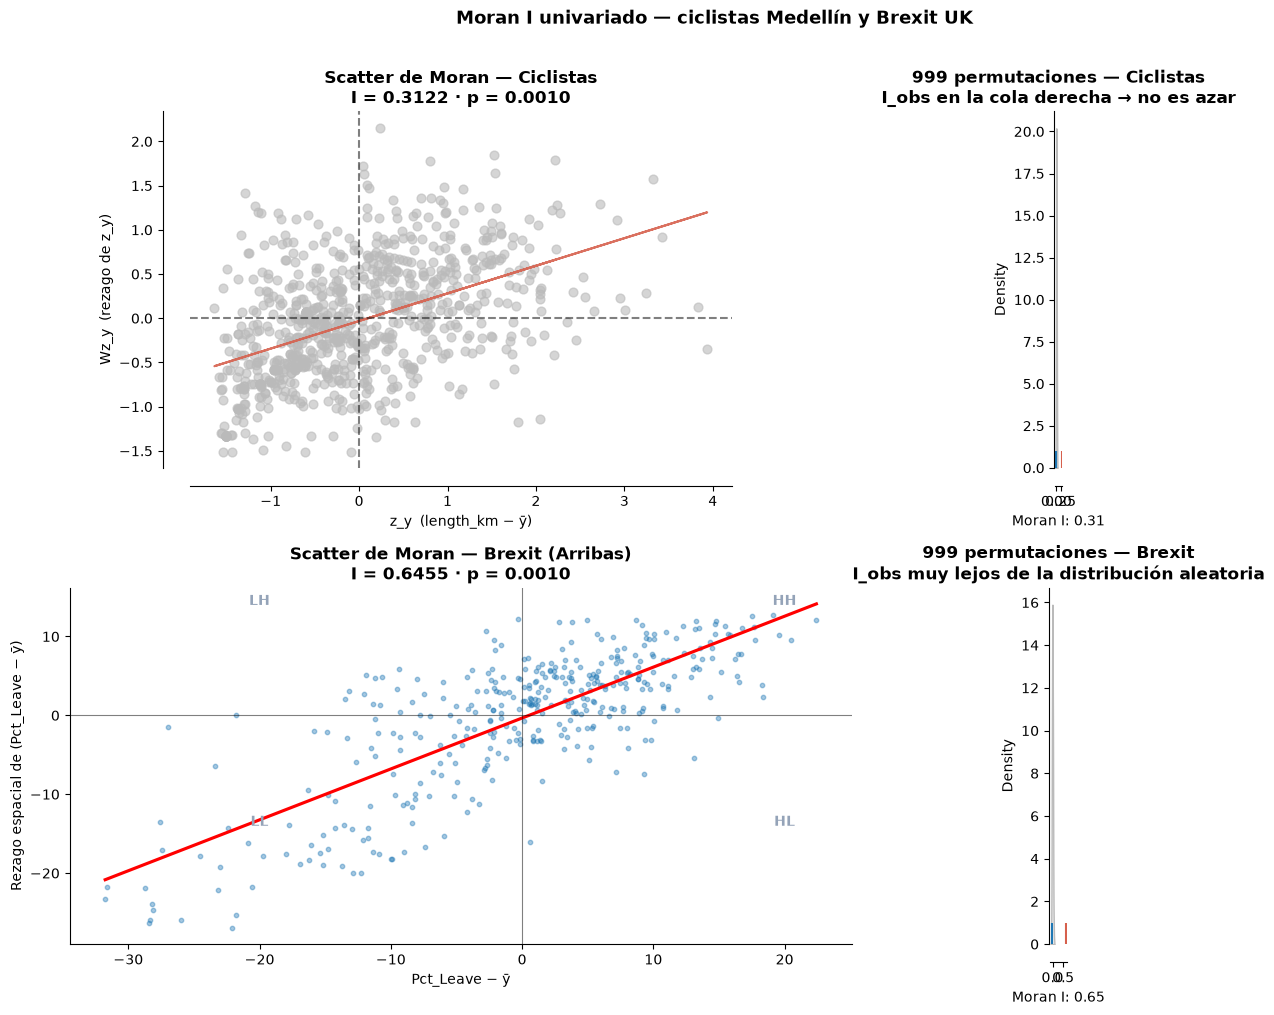

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA 2 — Scatter plots + distribuciones de permutaciones
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Ciclistas
esda_plot.moran_scatterplot(m_cic, ax=axes[0,0])
axes[0,0].set_title(f'Scatter de Moran — Ciclistas\n'
                    f'I = {m_cic.I:.4f} · p = {m_cic.p_sim:.4f}',
                    fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('z_y  (length_km − ȳ)', fontsize=10)
axes[0,0].set_ylabel('Wz_y  (rezago de z_y)', fontsize=10)

esda_plot.plot_moran_simulation(m_cic, ax=axes[0,1])
axes[0,1].set_title('999 permutaciones — Ciclistas\n'
                    'I_obs en la cola derecha → no es azar',
                    fontsize=12, fontweight='bold')

# Brexit
db['Pct_Leave_std']     = db['Pct_Leave']  - db['Pct_Leave'].mean()
db['Pct_Leave_lag_std'] = weights.lag_spatial(w_brex, db['Pct_Leave_std'])

seaborn.regplot(x='Pct_Leave_std', y='Pct_Leave_lag_std',
                ci=None, data=db, line_kws={'color':'r'},
                scatter_kws={'alpha':0.4, 's':10}, ax=axes[1,0])
axes[1,0].axvline(0, c='k', alpha=0.5, lw=0.8)
axes[1,0].axhline(0, c='k', alpha=0.5, lw=0.8)
for txt,(xt,yt) in [('HH',(20,14)),('LL',(-20,-14)),
                    ('HL',(20,-14)),('LH',(-20,14))]:
    axes[1,0].text(xt,yt,txt,fontsize=10,color='#94a3b8',
                  fontweight='bold',ha='center')
axes[1,0].set_title(f'Scatter de Moran — Brexit (Arribas)\n'
                    f'I = {m_brex.I:.4f} · p = {m_brex.p_sim:.4f}',
                    fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Pct_Leave − ȳ', fontsize=10)
axes[1,0].set_ylabel('Rezago espacial de (Pct_Leave − ȳ)', fontsize=10)

esda_plot.plot_moran_simulation(m_brex, ax=axes[1,1])
axes[1,1].set_title('999 permutaciones — Brexit\n'
                    'I_obs muy lejos de la distribución aleatoria',
                    fontsize=12, fontweight='bold')

plt.suptitle('Moran I univariado — ciclistas Medellín y Brexit UK',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/s06_A_moran_univariado.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Parte B — Del patrón global al patrón local

Moran I nos dijo: **existe un patrón espacial**.

Ahora preguntamos: **¿cómo se relaciona cada lugar con su entorno?**

La estrategia: en lugar de mirar la ciudad como un todo,
miramos cada zona por separado:

$$Y_i \quad \longleftrightarrow \quad (WY)_i$$

Y clasificamos cada zona en uno de cuatro cuadrantes:

| Cuadrante | $Y_i$ | $(WY)_i$ | Tipo |
|---|---|---|---|
| **HH** | $> \bar{Y}$ | $> \bar{Y}$ | Similitud positiva |
| **LL** | $< \bar{Y}$ | $< \bar{Y}$ | Similitud positiva |
| **HL** | $> \bar{Y}$ | $< \bar{Y}$ | Outlier positivo |
| **LH** | $< \bar{Y}$ | $> \bar{Y}$ | Outlier negativo |

> *Esta es una clasificación descriptiva — no garantiza significancia estadística.
> Eso lo veremos en la Clase 7 con el LISA.*

ȳ = 4.17 km  ·  s = 2.14 km
zᵢ > 0 → ciclista viaja MÁS que el promedio
zᵢ < 0 → ciclista viaja MENOS que el promedio



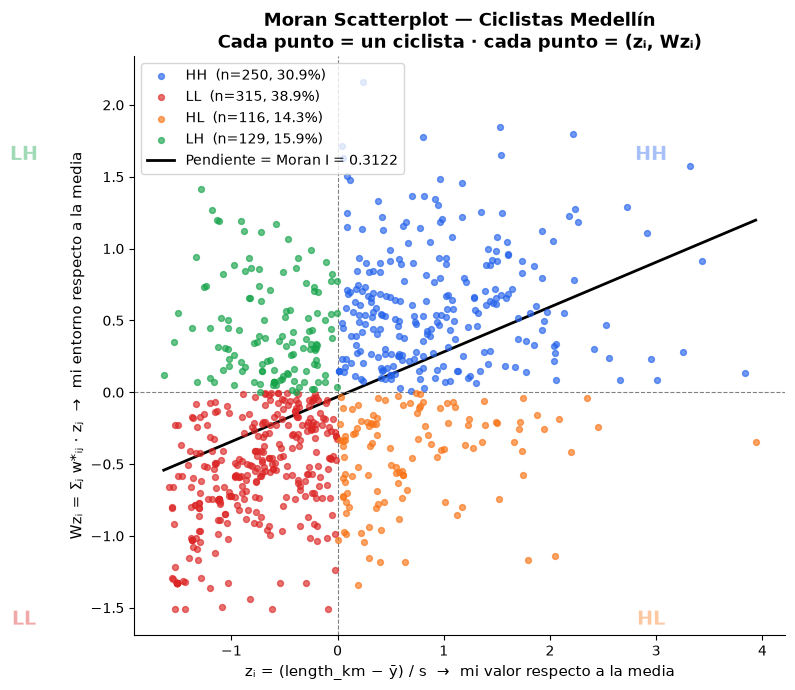

─── Ciclistas por cuadrante ──────────────────────────────────────────
  HH: 250 ciclistas (30.9%)
  LL: 315 ciclistas (38.9%)
  HL: 116 ciclistas (14.3%)
  LH: 129 ciclistas (15.9%)

─── Qué representa cada punto ───────────────────────────────────────
  Cada punto NO representa una variable.
  Cada punto NO representa un vecino.
  Cada punto representa UN LUGAR y la relación entre ese lugar y su entorno.

→ La pendiente de la recta = Moran I global.
  El Scatterplot muestra de dónde viene ese número.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA B2 — Moran Scatterplot: cada punto es un lugar
# Ciclistas Medellín · zᵢ = (yᵢ − ȳ) / s  ·  Wzᵢ = Σⱼ w*ᵢⱼ · zⱼ
# ─────────────────────────────────────────────────────────────────────────────

y_cic = ciclistas['length_km'].values

# Paso 1: estandarizar — zᵢ = (yᵢ − ȳ) / s
# El cero significa 'igual al promedio de la ciudad'
y_bar = y_cic.mean()
y_std = y_cic.std()
z_cic = (y_cic - y_bar) / y_std

print(f'ȳ = {y_bar:.2f} km  ·  s = {y_std:.2f} km')
print(f'zᵢ > 0 → ciclista viaja MÁS que el promedio')
print(f'zᵢ < 0 → ciclista viaja MENOS que el promedio')
print()

# Paso 2: rezago espacial de z — Wzᵢ = Σⱼ w*ᵢⱼ · zⱼ
# La condición espacial de los vecinos de i respecto al promedio
Wz_cic = weights.lag_spatial(w_cic, z_cic)

# Paso 3: asignar cuadrante según el par (zᵢ, Wzᵢ)
def cuadrante(z, wz):
    if   z > 0 and wz > 0: return 'HH'
    elif z < 0 and wz < 0: return 'LL'
    elif z > 0 and wz < 0: return 'HL'
    else:                   return 'LH'

ciclistas['z_cic']     = z_cic
ciclistas['Wz_cic']    = Wz_cic
ciclistas['cuadrante'] = [cuadrante(z, wz) for z, wz in zip(z_cic, Wz_cic)]

col_cuad = {'HH':'#2563EB', 'LL':'#DC2626', 'HL':'#F97316', 'LH':'#16A34A'}

# ── Scatter plot coloreado ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))

for cuad, color in col_cuad.items():
    mask = ciclistas['cuadrante'] == cuad
    ax.scatter(z_cic[mask], Wz_cic[mask],
               color=color, s=18, alpha=0.65, zorder=3,
               label=f'{cuad}  (n={mask.sum()}, {mask.mean()*100:.1f}%)')

# Recta de regresión — pendiente = Moran I
m_coef = np.polyfit(z_cic, Wz_cic, 1)
x_line = np.linspace(z_cic.min(), z_cic.max(), 100)
ax.plot(x_line, np.polyval(m_coef, x_line), 'k-', lw=2,
        label=f'Pendiente = Moran I = {m_coef[0]:.4f}')

# Origen (0,0) — la zona donde zᵢ = 0 y Wzᵢ = 0
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')

# Etiquetas de cuadrante
rng = max(abs(z_cic.min()), abs(z_cic.max())) * 0.75
rng_y = max(abs(Wz_cic.min()), abs(Wz_cic.max())) * 0.75
for txt, (xt, yt) in [('HH',(rng, rng_y)),('LL',(-rng,-rng_y)),
                       ('HL',(rng,-rng_y)),('LH',(-rng, rng_y))]:
    ax.text(xt, yt, txt, fontsize=14, fontweight='bold',
            color=col_cuad[txt], ha='center', alpha=0.4)

ax.set_xlabel('zᵢ = (length_km − ȳ) / s  →  mi valor respecto a la media', fontsize=11)
ax.set_ylabel('Wzᵢ = Σⱼ w*ᵢⱼ · zⱼ  →  mi entorno respecto a la media', fontsize=11)
ax.set_title('Moran Scatterplot — Ciclistas Medellín\n'
             'Cada punto = un ciclista · cada punto = (zᵢ, Wzᵢ)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('outputs/s06_B2_scatter_cuadrantes_cic.png', dpi=150, bbox_inches='tight')
plt.show()

print('─── Ciclistas por cuadrante ──────────────────────────────────────────')
for cuad in ['HH','LL','HL','LH']:
    n = (ciclistas['cuadrante']==cuad).sum()
    print(f'  {cuad}: {n:3d} ciclistas ({n/len(ciclistas)*100:.1f}%)')
print()
print('─── Qué representa cada punto ───────────────────────────────────────')
print('  Cada punto NO representa una variable.')
print('  Cada punto NO representa un vecino.')
print('  Cada punto representa UN LUGAR y la relación entre ese lugar y su entorno.')
print()
print('→ La pendiente de la recta = Moran I global.')
print('  El Scatterplot muestra de dónde viene ese número.')

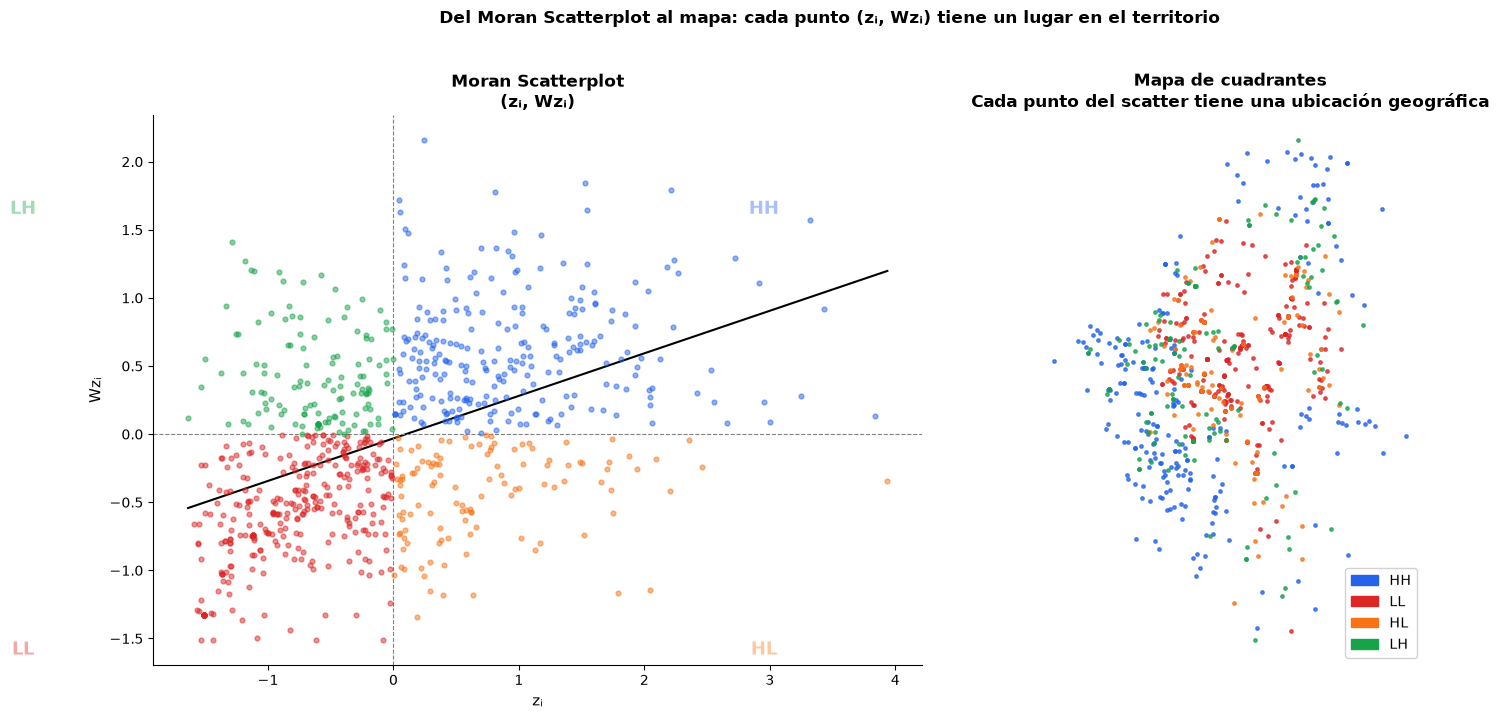

─── Lo que acabamos de hacer ────────────────────────────────────────
  Paso 1: calculamos zᵢ = (yᵢ − ȳ) / s  →  mi valor estandarizado
  Paso 2: calculamos Wzᵢ = Σⱼ w*ᵢⱼ · zⱼ  →  mi entorno estandarizado
  Paso 3: clasificamos cada lugar por el cuadrante de (zᵢ, Wzᵢ)
  Paso 4: devolvemos cada punto a su ubicación geográfica

─── Aviso importante ────────────────────────────────────────────────
  En este punto TODAVÍA NO hemos calculado el Local Moran.

  Lo que estamos viendo es la estructura descriptiva del Scatterplot:
  una clasificación geométrica de cada lugar según (zᵢ, Wzᵢ).
  No es un indicador estadístico. No tiene p-valor.

  La pregunta que queda abierta:
  ¿Qué tan fuerte y significativa es la asociación de cada lugar?

  Para eso necesitamos: Iᵢ = zᵢ · Wzᵢ  →  Módulo 8  →  Clase 7


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA B3 — Mapa de cuadrantes: del scatter al territorio
# Cada punto del scatter regresa a su ubicación geográfica
# ─────────────────────────────────────────────────────────────────────────────

import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Panel izquierdo: scatter plot (referencia) ───────────────────────────────
ax1 = axes[0]
for cuad, color in col_cuad.items():
    mask = ciclistas['cuadrante'] == cuad
    ax1.scatter(z_cic[mask], Wz_cic[mask],
                color=color, s=12, alpha=0.5, zorder=3)
ax1.plot(x_line, np.polyval(m_coef, x_line), 'k-', lw=1.5)
ax1.axhline(0, color='gray', lw=0.8, ls='--')
ax1.axvline(0, color='gray', lw=0.8, ls='--')
for txt, (xt, yt) in [('HH',(rng, rng_y)),('LL',(-rng,-rng_y)),
                       ('HL',(rng,-rng_y)),('LH',(-rng, rng_y))]:
    ax1.text(xt, yt, txt, fontsize=13, fontweight='bold',
             color=col_cuad[txt], ha='center', alpha=0.4)
ax1.set_xlabel('zᵢ', fontsize=11)
ax1.set_ylabel('Wzᵢ', fontsize=11)
ax1.set_title('Moran Scatterplot\n(zᵢ, Wzᵢ)', fontsize=12, fontweight='bold')

# ── Panel derecho: mapa de cuadrantes ───────────────────────────────────────
ax2 = axes[1]
ciclistas.plot(ax=ax2, color='#F1F5F9', markersize=4,
               edgecolor='none', zorder=1)
for cuad, color in col_cuad.items():
    mask = ciclistas['cuadrante'] == cuad
    ciclistas[mask].plot(ax=ax2, color=color,
                         markersize=6, alpha=0.75, zorder=3)
patches = [mpatches.Patch(color=c, label=q) for q, c in col_cuad.items()]
ax2.legend(handles=patches, loc='lower right', fontsize=10, framealpha=0.9)
ax2.set_title('Mapa de cuadrantes\nCada punto del scatter tiene una ubicación geográfica',
              fontsize=12, fontweight='bold')
ax2.set_axis_off()

plt.suptitle(
    'Del Moran Scatterplot al mapa: cada punto (zᵢ, Wzᵢ) tiene un lugar en el territorio',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('outputs/s06_B3_mapa_cuadrantes_cic.png', dpi=150, bbox_inches='tight')
plt.show()

print('─── Lo que acabamos de hacer ────────────────────────────────────────')
print('  Paso 1: calculamos zᵢ = (yᵢ − ȳ) / s  →  mi valor estandarizado')
print('  Paso 2: calculamos Wzᵢ = Σⱼ w*ᵢⱼ · zⱼ  →  mi entorno estandarizado')
print('  Paso 3: clasificamos cada lugar por el cuadrante de (zᵢ, Wzᵢ)')
print('  Paso 4: devolvemos cada punto a su ubicación geográfica')
print()
print('─── Aviso importante ────────────────────────────────────────────────')
print('  En este punto TODAVÍA NO hemos calculado el Local Moran.')
print()
print('  Lo que estamos viendo es la estructura descriptiva del Scatterplot:')
print('  una clasificación geométrica de cada lugar según (zᵢ, Wzᵢ).')
print('  No es un indicador estadístico. No tiene p-valor.')
print()
print('  La pregunta que queda abierta:')
print('  ¿Qué tan fuerte y significativa es la asociación de cada lugar?')
print()
print('  Para eso necesitamos: Iᵢ = zᵢ · Wzᵢ  →  Módulo 8  →  Clase 7')

---
## Parte C — Datos propios del equipo

El mismo procedimiento con los datos del proyecto.

**Dos pasos:**
1. Calcular el Moran I univariado de la variable Y con la W elegida
2. Análisis de sensibilidad: calcular I con al menos una W alternativa

**Para el Hito 2 deben reportar:**
- Moran I con p-valor y scatter plot
- Si el resultado era el esperado según su hipótesis
- Si el resultado es robusto a la elección de W
- **¿Dónde sospechan que está el clustering?** → lo verificarán en la Clase 7 con LISA

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELDA B1 — Datos propios: Moran I univariado + sensibilidad a W
# Modificar las líneas de configuración — el resto corre automáticamente
# ─────────────────────────────────────────────────────────────────────────────

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  CONFIGURACIÓN — cada equipo modifica solo estas líneas                 │
# └─────────────────────────────────────────────────────────────────────────┘
RUTA_DATOS    = 'data/mi_proyecto.gpkg'
VARIABLE_Y    = 'mi_variable_y'
NOMBRE_EQUIPO = 'Equipo X'

try:
    gdf = gpd.read_file(RUTA_DATOS)
    if gdf.crs is None or gdf.crs.is_geographic:
        gdf = gdf.to_crs('EPSG:3116')
    gdf[VARIABLE_Y] = pd.to_numeric(gdf[VARIABLE_Y], errors='coerce')
    gdf = gdf.dropna(subset=[VARIABLE_Y])

    geom = gdf.geometry.geom_type.unique()[0]
    w_p  = (Queen.from_dataframe(gdf) if geom in ['Polygon','MultiPolygon']
            else KNN.from_dataframe(gdf, k=5))
    w_p.transform = 'r'
    tipo_w = 'Queen' if geom in ['Polygon','MultiPolygon'] else 'KNN k=5'

    y_p = gdf[VARIABLE_Y].values

    # ── Moran I univariado ────────────────────────────────────────────────────
    m_uni = esda.Moran(y_p, w_p, permutations=999)
    print(f'─── {NOMBRE_EQUIPO} · {tipo_w} ──────────────────────────────────')
    print(f'Moran I  = {m_uni.I:.4f}')
    print(f'p-valor  = {m_uni.p_sim:.4f}')
    print(f'E[I]     = {m_uni.EI:.4f}')
    print()
    if m_uni.p_sim < 0.05:
        dir = 'POSITIVA (clustering)' if m_uni.I > m_uni.EI else 'NEGATIVA (dispersión)'
        print(f'→ Autocorrelación espacial {dir} significativa')
    else:
        print('→ Sin evidencia de autocorrelación espacial (p > 0.05)')
    print()
    print('─── Hipótesis para la Clase 7 ───────────────────────────────────────')
    print('  Dado el Moran I que encontramos, ¿en qué zona del territorio')
    print('  sospechan que está el clustering?')
    print('  Anótenlo en la bitácora antes de calcular el LISA en la Clase 7.')

    # ── Scatter plot ──────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    esda_plot.moran_scatterplot(m_uni, ax=axes[0])
    axes[0].set_title(f'Scatter de Moran — {NOMBRE_EQUIPO}\n'
                      f'I = {m_uni.I:.4f} · p = {m_uni.p_sim:.4f}',
                      fontsize=12, fontweight='bold')
    esda_plot.plot_moran_simulation(m_uni, ax=axes[1])
    axes[1].set_title('Distribución de permutaciones', fontsize=12, fontweight='bold')
    plt.suptitle(f'{NOMBRE_EQUIPO} — Moran I univariado',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'outputs/s06_B_{NOMBRE_EQUIPO.replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f'⚠ No se pudo cargar el archivo: {e}')
    print('  Actualiza RUTA_DATOS y VARIABLE_Y con los valores correctos.')

⚠ No se pudo cargar el archivo: data/mi_proyecto.gpkg: No such file or directory
  Actualiza RUTA_DATOS y VARIABLE_Y con los valores correctos.


---
## Parte D — Apertura del Hito 2

### ¿Qué debe contener el Hito 2?

| # | Elemento | Descripción |
|---|---|---|
| 1 | **W justificada** | Frase de vecindad completa · tipo de W · parámetro · justificación teórica |
| 2 | **Moran I univariado** | I con p-valor · scatter plot · distribución de permutaciones · interpretación sustantiva |
| 3 | **Sensibilidad a W** | I con al menos una W alternativa · ¿el resultado es robusto? |
| 4 | **Hipótesis local** | ¿En qué zona del territorio sospechan que está el clustering? → se verificará con LISA en la Clase 7 |

### La historia hasta aquí

```
W  →  WY  →  Y vs. WY  →  Moran I  →  ¿existe el patrón?
```

### La pregunta que queda abierta para la Clase 7

> *Sabemos que existe el patrón. Moran I = 0.31, p < 0.001 (ciclistas).*
> *Pero ese número describe toda la ciudad con un solo valor.*
> ***¿Dónde está ese patrón en el territorio?***

Esa es la pregunta del diagnóstico **local** — Clase 7.

---
*CM0866 · Juan Pablo Ospina Zapata · EAFIT 2026*